In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def simulate_realistic_viewport(num_steps, damping=0.99, step_size=1, start_yaw=0):
    """
    Simulates a more realistic viewport using a mean-reverting
    random walk (Ornstein-Uhlenbeck process).
    
    'damping' pulls the gaze back to the center (0 or 180).
    """
    yaw_trajectory = np.zeros(num_steps)
    pitch_trajectory = np.zeros(num_steps)
    
    current_yaw_drift = 0
    current_pitch_drift = 0
    
    yaw_trajectory[0] = start_yaw
    pitch_trajectory[0] = 0

    for i in range(1, num_steps):
        # Get random steps
        yaw_step = np.random.choice([-step_size, step_size])
        pitch_step = np.random.choice([-step_size, step_size])
        
        # Apply the mean-reverting logic
        # new_position = (old_position * damping) + random_step
        current_yaw_drift = (current_yaw_drift * damping) + yaw_step
        current_pitch_drift = (current_pitch_drift * damping) + pitch_step
        
        # Yaw: Add to start and wrap
        yaw_trajectory[i] = (start_yaw + current_yaw_drift) % 360
        
        # Pitch: Clamp
        pitch_trajectory[i] = np.clip(current_pitch_drift, -90, 90)
        
    return yaw_trajectory, pitch_trajectory

if __name__ == '__main__':
    # A damping of 0.99 means it reverts slowly. A damping of 0.90 would revert very quickly.
    yaw, pitch = simulate_realistic_viewport(num_steps=2000, damping=0.99, step_size=1.5, start_yaw=180)

In [4]:
# def get_required_tiles(center_yaw, center_pitch, n=12, fov_yaw=90.0, fov_pitch=90.0):
#     """
#     Robust tile selection for 360° video: tests tile centers against viewport FOV.
#     Correctly handles yaw wrapping (0°/360°) and pitch poles (±90°).
#     Returns list of (tile_x, tile_y) with 0-based indices.
#     """
#     tile_size_yaw = 360.0 / n
#     tile_size_pitch = 180.0 / n
    
#     # Tile centers in yaw [0..360) and pitch [+90..-90] (top to bottom)
#     yaw_centers = (np.arange(n) + 0.5) * tile_size_yaw            # 0..360
#     pitch_centers = 90.0 - (np.arange(n) + 0.5) * tile_size_pitch  # +90..-90

#     # Normalize center_yaw to [0,360)
#     cy = float(center_yaw) % 360.0
#     cp = float(center_pitch)

#     # Angular distance on circle: wrap-aware difference in [-180,180]
#     delta_yaw = ((yaw_centers - cy + 180.0) % 360.0) - 180.0
#     yaw_mask = np.abs(delta_yaw) <= (fov_yaw / 2.0)
    
#     # Pitch is linear; clamp center to [-90,90]
#     cp_clamped = np.clip(cp, -90, 90)
#     pitch_mask = np.abs(pitch_centers - cp_clamped) <= (fov_pitch / 2.0)

#     required = []
#     y_idxs = np.nonzero(yaw_mask)[0]
#     p_idxs = np.nonzero(pitch_mask)[0]
#     for xi in y_idxs:
#         for yi in p_idxs:
#             required.append((int(xi), int(yi)))
#     return required

In [5]:
def get_required_tiles(center_yaw, center_pitch, n=12, fov_yaw=90.0, fov_pitch=90.0):
    """
    Given a center yaw and pitch, compute the required tiles.

    Parameters:
    - center_yaw: Center yaw angle in degrees (0-360).
    - center_pitch: Center pitch angle in degrees (-90 to +90).
    - n: Number of tiles per axis (e.g., 8x8 grid).
    - fov_yaw: Field of view in yaw direction in degrees.
    - fov_pitch: Field of view in pitch direction in degrees.

    Returns:
    - A list of (tile_x, tile_y) tuples representing required tiles.
    """
    tile_size_yaw = 360 / n
    tile_size_pitch = 180 / n  # Pitch ranges from -90 to +90

    # Calculate the FOV boundaries
    half_fov_yaw = fov_yaw / 2
    half_fov_pitch = fov_pitch / 2

    # Determine the min and max yaw and pitch
    min_yaw = (center_yaw - half_fov_yaw) % 360
    max_yaw = (center_yaw + half_fov_yaw) % 360
    min_pitch = max(center_pitch - half_fov_pitch, -90)
    max_pitch = min(center_pitch + half_fov_pitch, 90)

    required_tiles = set()

    # Calculate tile indices for yaw
    if min_yaw < max_yaw:
        yaw_indices = range(int(min_yaw // tile_size_yaw), int(max_yaw // tile_size_yaw) + 1)
    else:
        yaw_indices = list(range(int(min_yaw // tile_size_yaw), n)) + list(range(0, int(max_yaw // tile_size_yaw) + 1))

    # Calculate tile indices for pitch
    pitch_indices = range(int((min_pitch + 90) // tile_size_pitch), int((max_pitch + 90) // tile_size_pitch) + 1)

    # Combine yaw and pitch indices to get required tiles
    for yaw_index in yaw_indices:
        for pitch_index in pitch_indices:
            required_tiles.add((yaw_index % n, pitch_index))

    return list(required_tiles)

In [6]:
def simulate_viewport_with_tiles(
    num_steps,
    n=8,
    fov_yaw=90.0,
    fov_pitch=90.0,
    damping=0.99,
    step_size=1.5,
    start_yaw=180,
    start_pitch=0
):
    """
    Simulates a realistic viewport trajectory and tracks required tiles at each step.

    New params:
    - view_tiles: tuple (tiles_x, tiles_y). If provided, overrides fov_yaw/fov_pitch to cover that many tiles.
    - view_tiles_total: integer total tiles to cover (will use ceil(sqrt(total)) for both axes).
    """
    
    # Initialize trajectories
    yaw_trajectory = np.zeros(num_steps)
    pitch_trajectory = np.zeros(num_steps)
    
    # Mean-reverting drift values
    current_yaw_drift = 0
    current_pitch_drift = 0
    
    # Set starting position
    yaw_trajectory[0] = start_yaw
    pitch_trajectory[0] = start_pitch
    
    # Store required tiles for each frame
    tiles_per_frame = []
    
    # Get initial tiles
    initial_tiles = get_required_tiles(start_yaw, start_pitch, n, fov_yaw, fov_pitch)
    tiles_per_frame.append(set(initial_tiles))
    
    # Simulate trajectory
    for i in range(1, num_steps):
        # Random steps
        yaw_step = np.random.choice([-step_size, step_size])
        pitch_step = np.random.choice([-step_size, step_size])
        
        # Apply mean-reverting logic
        current_yaw_drift = (current_yaw_drift * damping) + yaw_step
        current_pitch_drift = (current_pitch_drift * damping) + pitch_step
        
        # Update positions
        yaw_trajectory[i] = (start_yaw + current_yaw_drift) % 360
        pitch_trajectory[i] = np.clip(current_pitch_drift, -90, 90)
        
        # Get required tiles for this viewport position
        required_tiles = get_required_tiles(yaw_trajectory[i], pitch_trajectory[i], n, fov_yaw, fov_pitch)
        tiles_per_frame.append(set(required_tiles))
    
    # Convert to 2D array format (for easier processing)
    # Find max number of tiles needed at any frame
    max_tiles = max(len(tiles) for tiles in tiles_per_frame)
    
    # Create 2D array: rows=frames, cols=tile indices
    # Use -1 to indicate unused slots
    tiles_array = np.full((num_steps, max_tiles), -1, dtype=int)
    
    for frame_idx, tiles_set in enumerate(tiles_per_frame):
        tiles_list = sorted(list(tiles_set))
        for tile_idx, tile in enumerate(tiles_list):
            # Store as linear index: tile_y * n + tile_x
            tiles_array[frame_idx, tile_idx] = tile[1] * n + tile[0]
    
    return yaw_trajectory, pitch_trajectory, tiles_per_frame, tiles_array


Frame 0: Yaw=180.00, Pitch=0.00, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 1: Yaw=185.00, Pitch=5.00, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 2: Yaw=189.95, Pitch=-0.05, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 3: Yaw=184.85, Pitch=-5.05, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 4: Yaw=189.80, Pitch=-10.00, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 5: Yaw=194.70, Pitch=-4.90, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 6: Yaw=189.56, Pitch=-9.85, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 7: Yaw=184.46, Pitch=-4.75, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 8: Yaw=189.42, Pitch=-9.70, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 9: Yaw=194.32, Pitch=-14.61, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 10: Yaw=199.18, Pitch=-9.46, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 11: Yaw=193.99, Pitch=-14.37, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 12: Yaw=198.85, Pitch=-19.22, Tiles={(1, 1), (1, 2), (2, 1), (2, 2)}
Frame 13: Yaw=193.66, Pitch=-14.03, Tiles={(1,

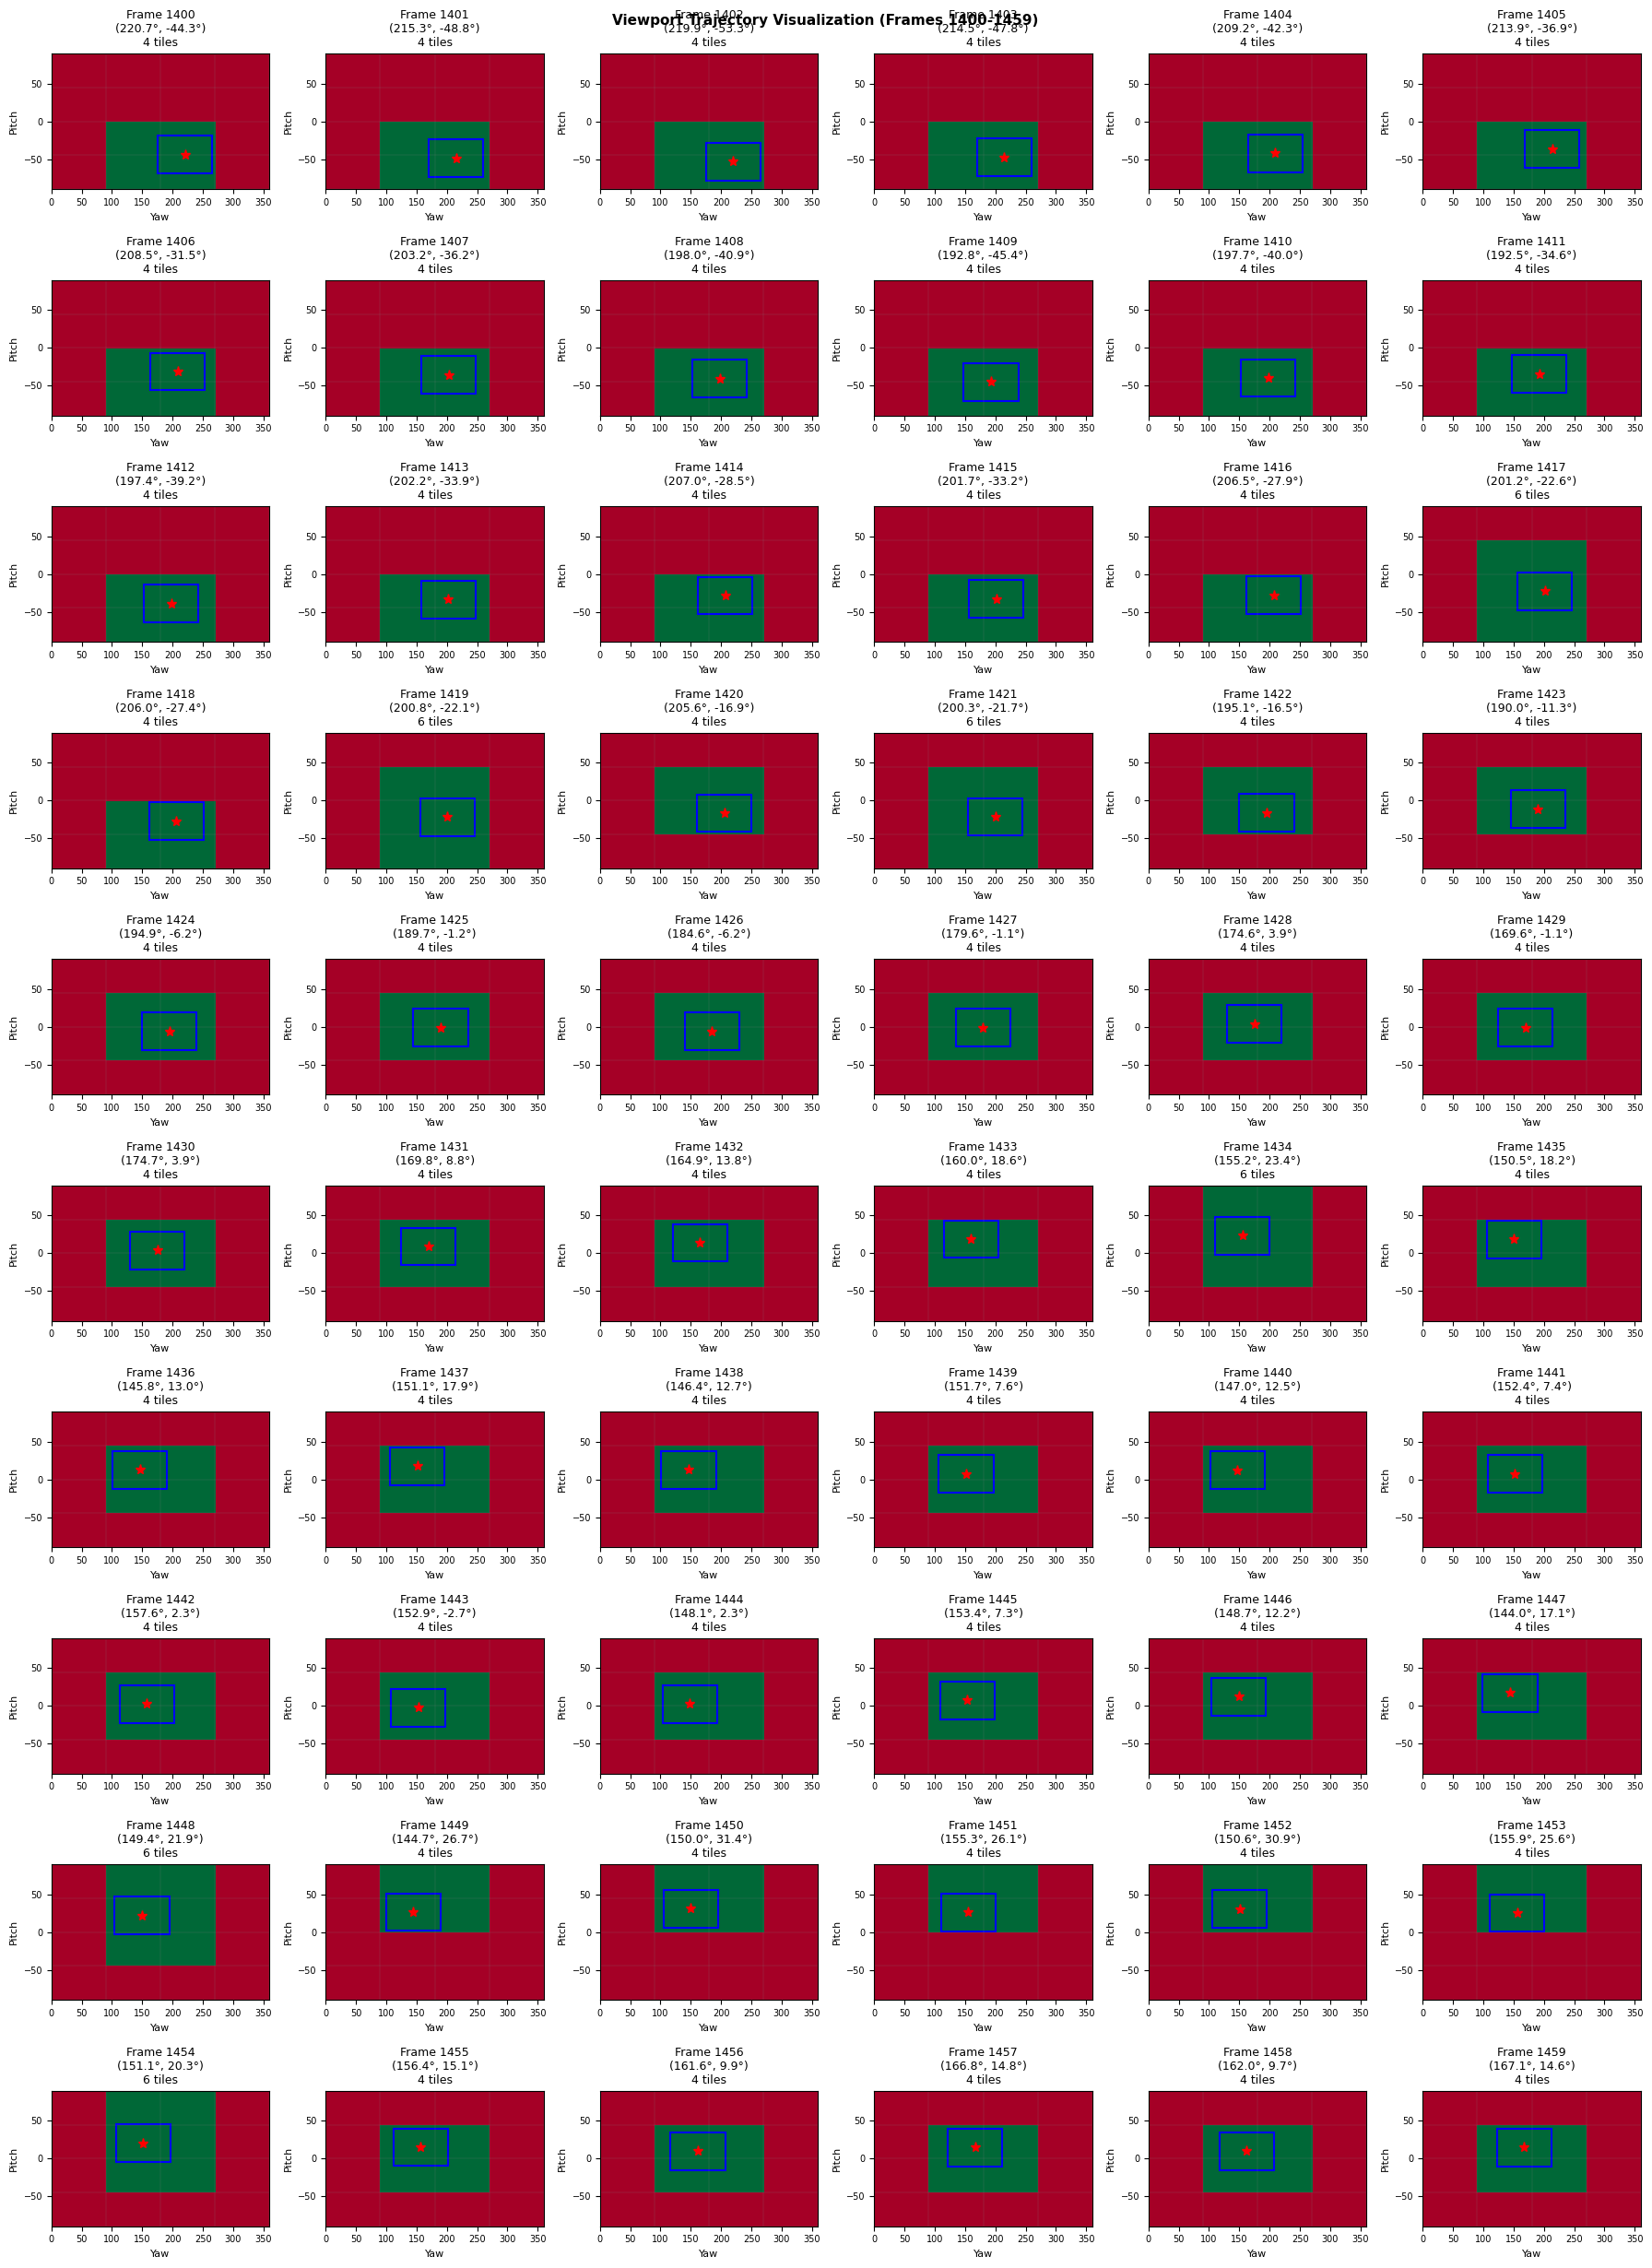

In [11]:
def visualize_trajectory_sequence(
    yaw, 
    pitch, 
    tiles_per_frame, 
    n=8, 
    fov_yaw=90, 
    fov_pitch=90,
    start_frame=0, 
    num_frames_to_show=6, 
    cols=3
):
    """
    Visualizes a sequence of frames from the trajectory showing viewport and required tiles.
    
    Parameters:
    - yaw: Array of yaw positions
    - pitch: Array of pitch positions
    - tiles_per_frame: List of sets containing required tiles
    - n: Grid size (8x8)
    - fov_yaw, fov_pitch: Field of view
    - start_frame: Which frame to start visualization from
    - num_frames_to_show: How many frames to display
    - cols: Number of columns in subplot grid
    """
    rows = int(np.ceil(num_frames_to_show / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = axes.flatten() if num_frames_to_show > 1 else [axes]
    
    for idx in range(num_frames_to_show):
        frame_num = start_frame + idx
        if frame_num >= len(yaw):
            axes[idx].axis('off')
            continue
            
        ax = axes[idx]
        
        # Get viewport parameters for this frame
        center_yaw = yaw[frame_num]
        center_pitch = pitch[frame_num]
        required_tiles = tiles_per_frame[frame_num]
        
        # Create tile grid
        tile_grid = np.zeros((n, n))
        
        # Mark required tiles
        for tile_x, tile_y in required_tiles:
            if 0 <= tile_x < n and 0 <= tile_y < n:
                tile_grid[tile_y, tile_x] = 1
        
        # Display the grid
        ax.imshow(
            tile_grid,  
            interpolation='nearest', 
            origin='lower',
            cmap='RdYlGn',
            extent=[0, 360, -90, 90], 
            aspect='auto', 
            vmin=0, 
            vmax=1
        )
        
        # Draw grid lines
        tile_size_yaw = 360 / n
        tile_size_pitch = 180 / n
        
        for i in range(n + 1):
            ax.axvline(
                i * tile_size_yaw, color='gray', linewidth=0.3, alpha=0.5
            )
            ax.axhline(
                -90 + i * tile_size_pitch, color='gray', linewidth=0.3, alpha=0.5
           )
        
        # Draw viewport FOV rectangle
        half_fov_yaw = fov_yaw / 2
        half_fov_pitch = fov_pitch / 2
        
        min_yaw = center_yaw - half_fov_yaw
        max_yaw = center_yaw + half_fov_yaw
        min_pitch = max(center_pitch - half_fov_pitch, -90)
        max_pitch = min(center_pitch + half_fov_pitch, 90)
        
        # Handle yaw wrapping
        if min_yaw < 0 or max_yaw > 360:
            if min_yaw < 0:
                ax.add_patch(plt.Rectangle(
                    (min_yaw + 360, min_pitch), 
                    -min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (0, min_pitch), 
                    max_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
            else:
                ax.add_patch(plt.Rectangle(
                    (min_yaw, min_pitch), 
                    360 - min_yaw, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
                ax.add_patch(plt.Rectangle(
                    (0, min_pitch), 
                    max_yaw - 360, 
                    max_pitch - min_pitch,
                    fill=False, 
                    edgecolor='blue', 
                    linewidth=1.5
                ))
        else:
            ax.add_patch(plt.Rectangle(
                (min_yaw, min_pitch), 
                fov_yaw, 
                max_pitch - min_pitch,
                fill=False, 
                edgecolor='blue', 
                linewidth=1.5
            ))
        
        # Mark center
        ax.plot(center_yaw, center_pitch, 'r*', markersize=8)
        
        # Set labels and limits
        ax.set_xlim(0, 360)
        ax.set_ylim(-90, 90)
        ax.set_title(f'Frame {frame_num}\n({center_yaw:.1f}°, {center_pitch:.1f}°)\n{len(required_tiles)} tiles',
                     fontsize=9)
        ax.set_xlabel('Yaw', fontsize=8)
        ax.set_ylabel('Pitch', fontsize=8)
        ax.tick_params(labelsize=7)
    
    # Hide any unused subplots
    for idx in range(num_frames_to_show, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Viewport Trajectory Visualization (Frames {start_frame}-{start_frame+num_frames_to_show-1})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    num_frames = 2000
    n_tiles = 4

    yaw, pitch, tiles_per_frame, tiles_array = simulate_viewport_with_tiles(
        num_steps=num_frames,
        n=n_tiles,
        fov_yaw=90,
        fov_pitch=50,
        damping=0.99,
        step_size=5, # 1.5
        start_yaw=180,
        start_pitch=0
    )
    for i in range(num_frames):
        print(f"Frame {i}: Yaw={yaw[i]:.2f}, Pitch={pitch[i]:.2f}, Tiles={tiles_per_frame[i]}")

    print("Visualizing trajectory sequence...\n")

    visualize_trajectory_sequence(
        yaw, 
        pitch, 
        tiles_per_frame, 
        n=n_tiles, 
        fov_yaw=90, 
        fov_pitch=50,
        start_frame=1400, 
        num_frames_to_show=60, 
        cols=6
    )